# Introduction to Ocean Modelling : Exercise 4, 5, 6 and 7

### Elsie Chilwane (CHLMOT003) 

### 2/06/2026

### Marcello Vichi 

DISCLAIMER: AI was used in following way:

https://claude.ai/share/fca3c7cf-767e-4653-9d7e-153d2676597d

In [3]:
import numpy as np
import matplotlib.pyplot as plt


**Exercise 4**

Calculate the Taylor series expansion for the following univariate
functions f (x) about the point x = x0. Only show the series terms
until the truncation error is O

(x − x0)3
and upload a picture or a
document on your GitHub:
1. f (x) = x/x+1
2. f (x) = 2x2/x4
3. f (x) = ln/x2

**Exercise 5**

Consider the implicit Euler backward scheme
C n+1 = C n
(1 + k∆t)
• This scheme is unconditionally stable
• Demonstrate that this is true by using the same method used in the
previous slide. Upload a picture or a docume

To understand the concepts: Implicit Euler Backward Scheme:

To solve differential equations on a computer, continuous time has to be discretized, which means broken down into discrete steps. 

The Euler backwards scheme is some of the methids used to calculate how some variable e.g)concentration changes over time 

C - cocnentration 
C^n - current step time
C^ n+1 - future step time

It is implicit because it is used to evaluate the rate of change using a future unknown value of a variable, so thats C^n+1

C n+1 = C n (1 + k∆t) ~ the unknown future value of a variable becomes the subject of the formula. 

Stabilility, relies on the denominator always being positive. 

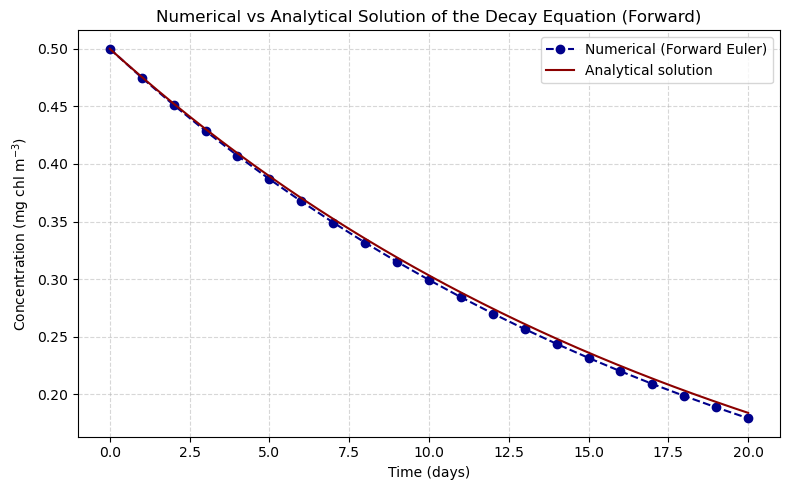

In [13]:
"""
A numerical solution of the decay equation.
"""
t0 = 0.       # time is in days
tn = 20.
dt = 1.
kappa = 0.05  # day^-1
C0 = 0.5      # mg chl/m3

def F(k, C):  # define the function for the right hand side of the equation
    return -k * C

# compute the total number of steps
Ntot = int(np.floor((tn - t0) / dt) + 1)

# initialization
C = np.zeros(Ntot)
t = C.copy()  # this array stores the time and has the same size as C
t[0] = t0
C[0] = C0

# start the loop
for n in range(Ntot - 1):
    C[n+1] = C[n] + F(kappa, C[n]) * dt
    t[n+1] = t[n] + dt

# analytical solution for comparison
t_exact = np.linspace(t0, tn, 200)
C_exact = C0 * np.exp(-kappa * t_exact)

# plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, C, 'o--', color='darkblue', label='Numerical (Forward Euler)')
ax.plot(t_exact, C_exact, '-', color='darkred', label='Analytical solution')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Concentration (mg chl m$^{-3}$)')
ax.set_title('Numerical vs Analytical Solution of the Decay Equation (Forward)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Figure 1: Numerical vs Analytical Solution of the Decay Equation taken from the Lecture Notes (Forward Euler)**

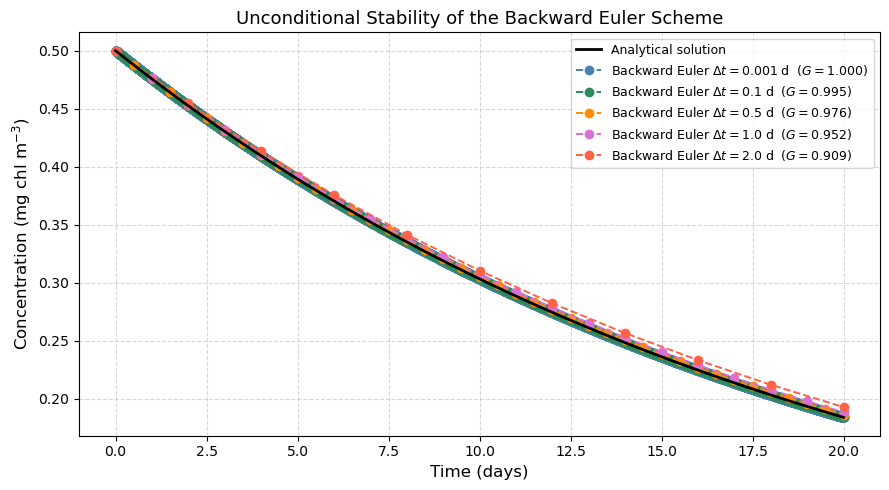

In [19]:

# Parameters
t0 = 0.
tn = 20.
k  = 0.05      # decay rate (day^-1), fixed
C0 = 0.5      # mg chl/m3
alpha = 1.0   # alpha=1 => pure backward Euler

# Timesteps to test — large dt values that would destroy forward Euler
dt_list = [0.001,0.1, 0.5, 1.0, 2.0, 2.2, 5.0, 10.0]

# Analytical solution on fine grid
t_exact = np.linspace(t0, tn, 300)
C_exact = C0 * np.exp(-k * t_exact)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_exact, C_exact, 'k-', linewidth=2, label='Analytical solution', zorder=5)

colors = ['steelblue', 'seagreen', 'darkorange', 'orchid', 'tomato']

for dt, color in zip(dt_list, colors):
    Ntot = int(np.floor((tn - t0) / dt)) + 1
    C = np.zeros(Ntot)
    t = np.zeros(Ntot)
    C[0] = C0
    t[0] = t0

    # Amplification factor G for backward Euler (alpha=1):
    #   C[n+1] = G * C[n],  where G = 1 / (1 + alpha*k*dt)
    G = 1.0 / (1.0 + alpha * k * dt)

    for n in range(Ntot - 1):
        C[n+1] = G * C[n]          # backward Euler step
        t[n+1] = t[n] + dt

    ax.plot(t, C, 'o--', color=color, linewidth=1.4,
            label=rf'Backward Euler $\Delta t={dt}$ d  ($G={G:.3f}$)')

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Concentration (mg chl m$^{-3}$)', fontsize=12)
ax.set_title('Unconditional Stability of the Backward Euler Scheme', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Figure 2: Unconditional Stablility of the Backward Euler Scheme**

**Exercise 6**

Modify the Euler-forward method implemented in the codes at the
beginning of this section (either the python or matlab version) and change
it into the Euler-backward method.
• Compare the results for different values of ∆t and upload your code and
results on the GitHub repository.

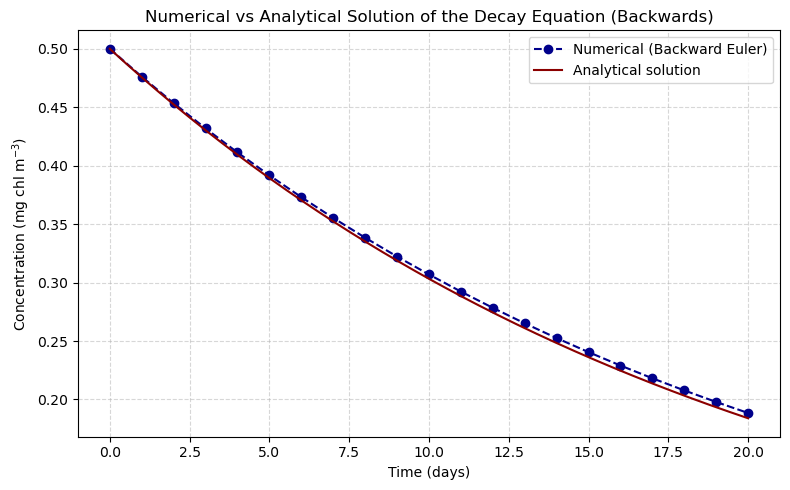

In [22]:

t0 = 0.       # time is in days
tn = 20.
dt = 1.
kappa = 0.05  # day^-1
C0 = 0.5      # mg chl/m3
alpha = 1.0 

def F(k, C):  # define the function for the right hand side of the equation
    return -k * C

# compute the total number of steps
Ntot = int(np.floor((tn - t0) / dt) + 1)

# initialization
C = np.zeros(Ntot)
t = C.copy()  # this array stores the time and has the same size as C
t[0] = t0
C[0] = C0

G = 1.0 / (1.0 + alpha * k * dt)


# start the loop
for n in range(Ntot - 1):
        C[n+1] = G * C[n]          # backward Euler step
        t[n+1] = t[n] + dt
    
# analytical solution for comparison
t_exact = np.linspace(t0, tn, 200)
C_exact = C0 * np.exp(-kappa * t_exact)

# plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, C, 'o--', color='darkblue', label='Numerical (Backward Euler)')
ax.plot(t_exact, C_exact, '-', color='darkred', label='Analytical solution')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Concentration (mg chl m$^{-3}$)')
ax.set_title('Numerical vs Analytical Solution of the Decay Equation (Backwards)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Figure 3: Numerical vs Analytical Solution of the Decay Equation taken from the Lecture Notes (Backward Euler)**

**Exercise 7**

Compare the analytical solution of the model presented in eq. (4) from
Exercise 2 with the numerical solution obtained using odeint in file
NP to NPD.ipynb. Check the code carefully to understand how the
right-end-side of the dynamical equation is implemented.
• Modify the notebook to answer the following questions and upload it on
your repository
1. What are the inputs and outputs in the function model? What kind
of objects are they?
2. Write the equtions for a new model to simulate the
nutrient-phytoplankton-detritus system (NPD). You will Include a
detritus variable D that is produced from the mortality of
phytoplankton and it is remineralized as a nutrient. You will need 2
additional parameters: the mortality rate (phytoplankton lysis) and
the remineralization rate
3. Write the code to solve the new model using odeint and propose
some reasonable values for the parameters that lead to a realistic
solution